In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\HP\Downloads\heart_v2.csv")

In [3]:
df.columns

Index(['age', 'sex', 'BP', 'cholestrol', 'heart disease'], dtype='object')

In [4]:
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [5]:
# Feature vable to X and Target variable to y
X = df.drop('heart disease',axis=1)
y = df['heart disease']

In [6]:
# Split the dataset into train and test datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7,test_size=0.3, random_state=42)

- Fiiting the deciion tree with default parameters, apart from mx_depth is 3 so that we can plot and read the tree

In [7]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [8]:
# Import libraries for Visualization
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus, graphviz

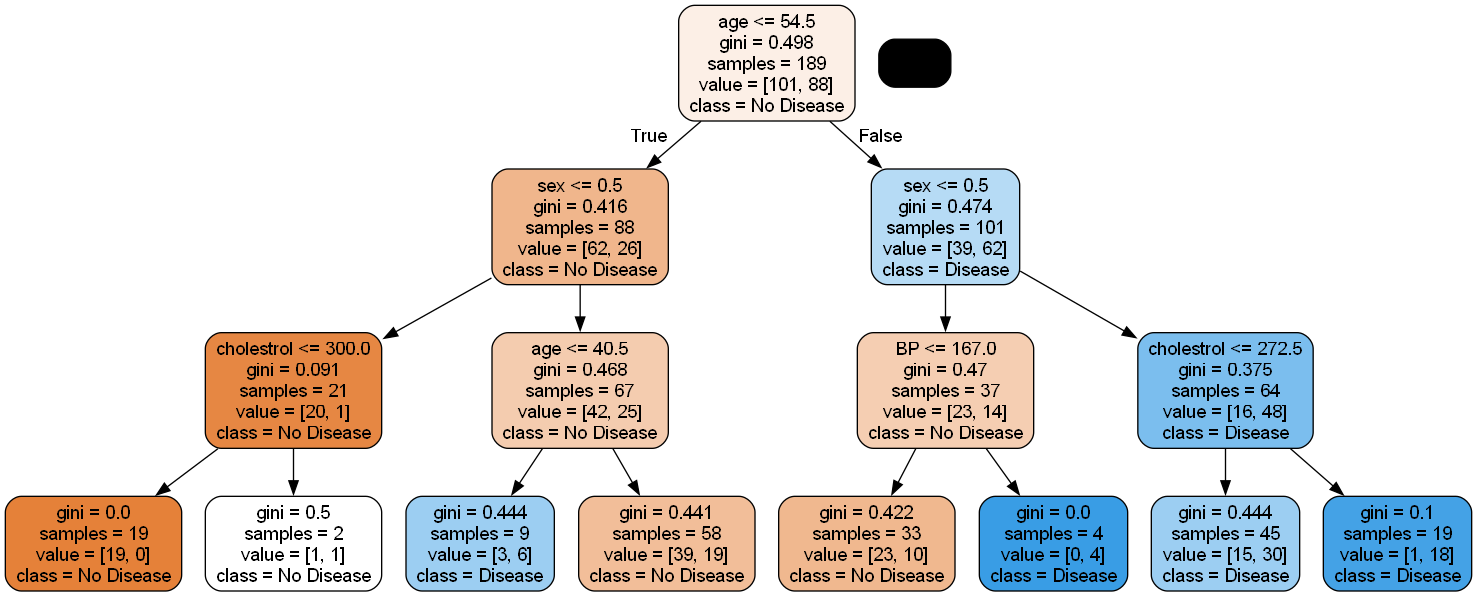

In [9]:
# Plotting the Tree
dot_data = StringIO()
export_graphviz(dt,out_file=dot_data,filled=True,rounded=True,
                feature_names=X.columns,class_names=['No Disease','Disease'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

- Creating helper functions to evaluate model performance and help plot the decision tree

In [10]:
def get_dt_graph(dt_classifier):
    dot_data = StringIO()
    export_graphviz(dt_classifier,out_file=dot_data,filled=True,
                    rounded=True,feature_names=X.columns,class_names=["No Disease","Disease"])
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return graph

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
def evaluate_model(dt_classifier):
    print("Train Metrics")
    print(f'Accuracy score {accuracy_score(y_train,dt_classifier.predict(X_train))}.')
    print(f'Confusion Matrix {confusion_matrix(y_train,dt_classifier.predict(X_train))}.')
    print("Test Metrics")
    print(f'Accuracy score {accuracy_score(y_test,dt_classifier.predict(X_test))}.')
    print(f'Confusion Matrix {confusion_matrix(y_test,dt_classifier.predict(X_test))}.')

# Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf = RandomForestClassifier(random_state=42,n_estimators=10, max_depth=3)

In [15]:
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=3, n_estimators=10, random_state=42)

In [16]:
rf.estimators_[0]

DecisionTreeClassifier(max_depth=3, max_features='sqrt',
                       random_state=1608637542)

In [17]:
sample_tree = rf.estimators_[4]

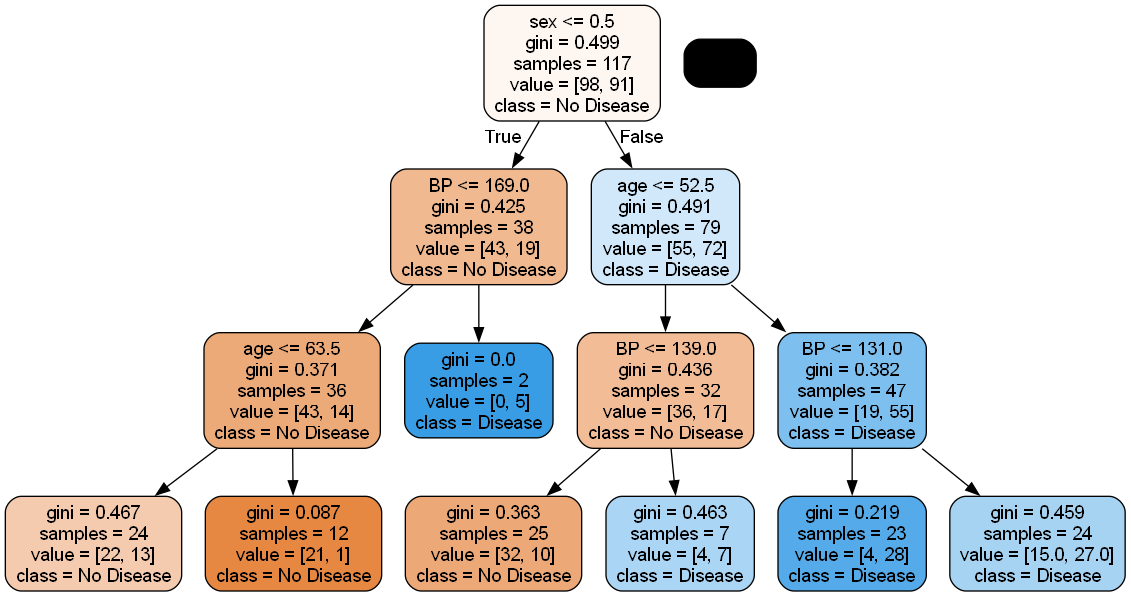

In [18]:
graph = get_dt_graph(sample_tree)
Image(graph.create_png(),width = 700, height=700)

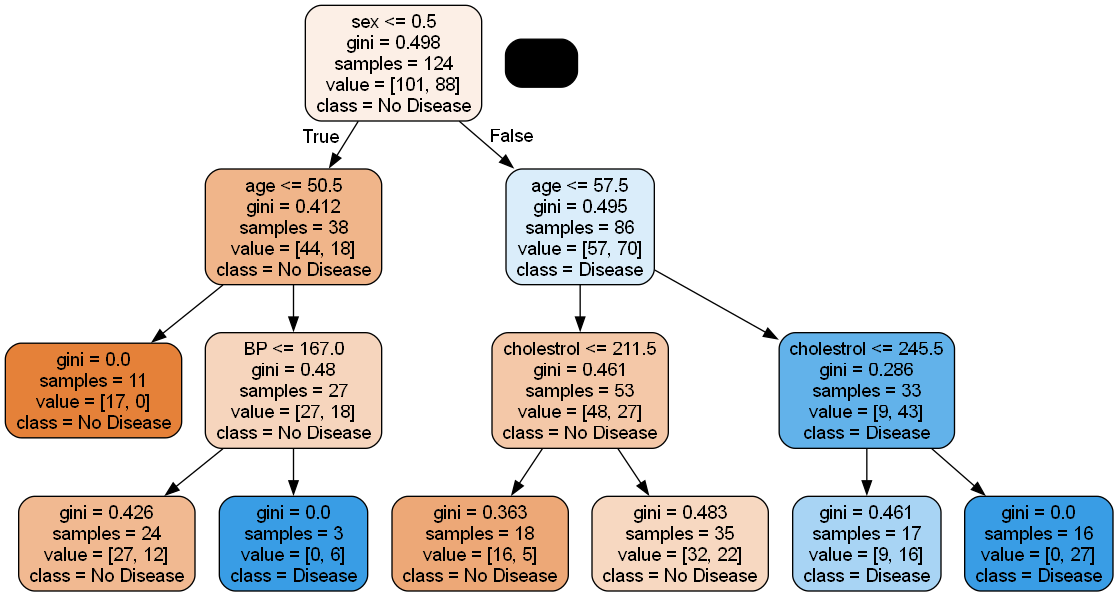

In [19]:
sample_tree2 = rf.estimators_[3]
graph2 = get_dt_graph(sample_tree2)
Image(graph2.create_png(), width = 700, height = 700)

In [20]:
evaluate_model(rf)

Train Metrics
Accuracy score 0.7407407407407407.
Confusion Matrix [[80 21]
 [28 60]].
Test Metrics
Accuracy score 0.6172839506172839.
Confusion Matrix [[35 14]
 [17 15]].


- GridSearch for Hyper-parameter Tuning


In [21]:
classifier_rf = RandomForestClassifier(random_state=42,n_jobs=-1)

In [22]:
# Create the parameter grid based on the results of random search 
params = {
    "max_depth" : [1,2,5,10,20],
    "min_samples_leaf" : [5,10,20,50,100],
    "max_features" : [2,3,4],
    "n_estimators" : [10,30,50,100,200]
}

In [23]:
from sklearn.model_selection import GridSearchCV

- Instantiate Grid Search Model

In [24]:
grid_search = GridSearchCV(estimator=classifier_rf,param_grid=params,
                           cv=4,n_jobs=-1,verbose=1,scoring="accuracy")

In [25]:
%%time
grid_search.fit(X,y)

Fitting 4 folds for each of 375 candidates, totalling 1500 fits
CPU times: total: 3.28 s
Wall time: 2min 23s


c:\Users\HP\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 2, 5, 10, 20],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [5, 10, 20, 50, 100],
                         'n_estimators': [10, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

In [26]:
rf_best = grid_search.best_estimator_

In [27]:
rf_best

RandomForestClassifier(max_depth=5, max_features=3, min_samples_leaf=5,
                       n_estimators=30, n_jobs=-1, random_state=42)

In [28]:
evaluate_model(rf_best)

Train Metrics
Accuracy score 0.8042328042328042.
Confusion Matrix [[87 14]
 [23 65]].
Test Metrics
Accuracy score 0.8024691358024691.
Confusion Matrix [[42  7]
 [ 9 23]].


In [29]:
sample_tree_best = rf_best.estimators_[0]

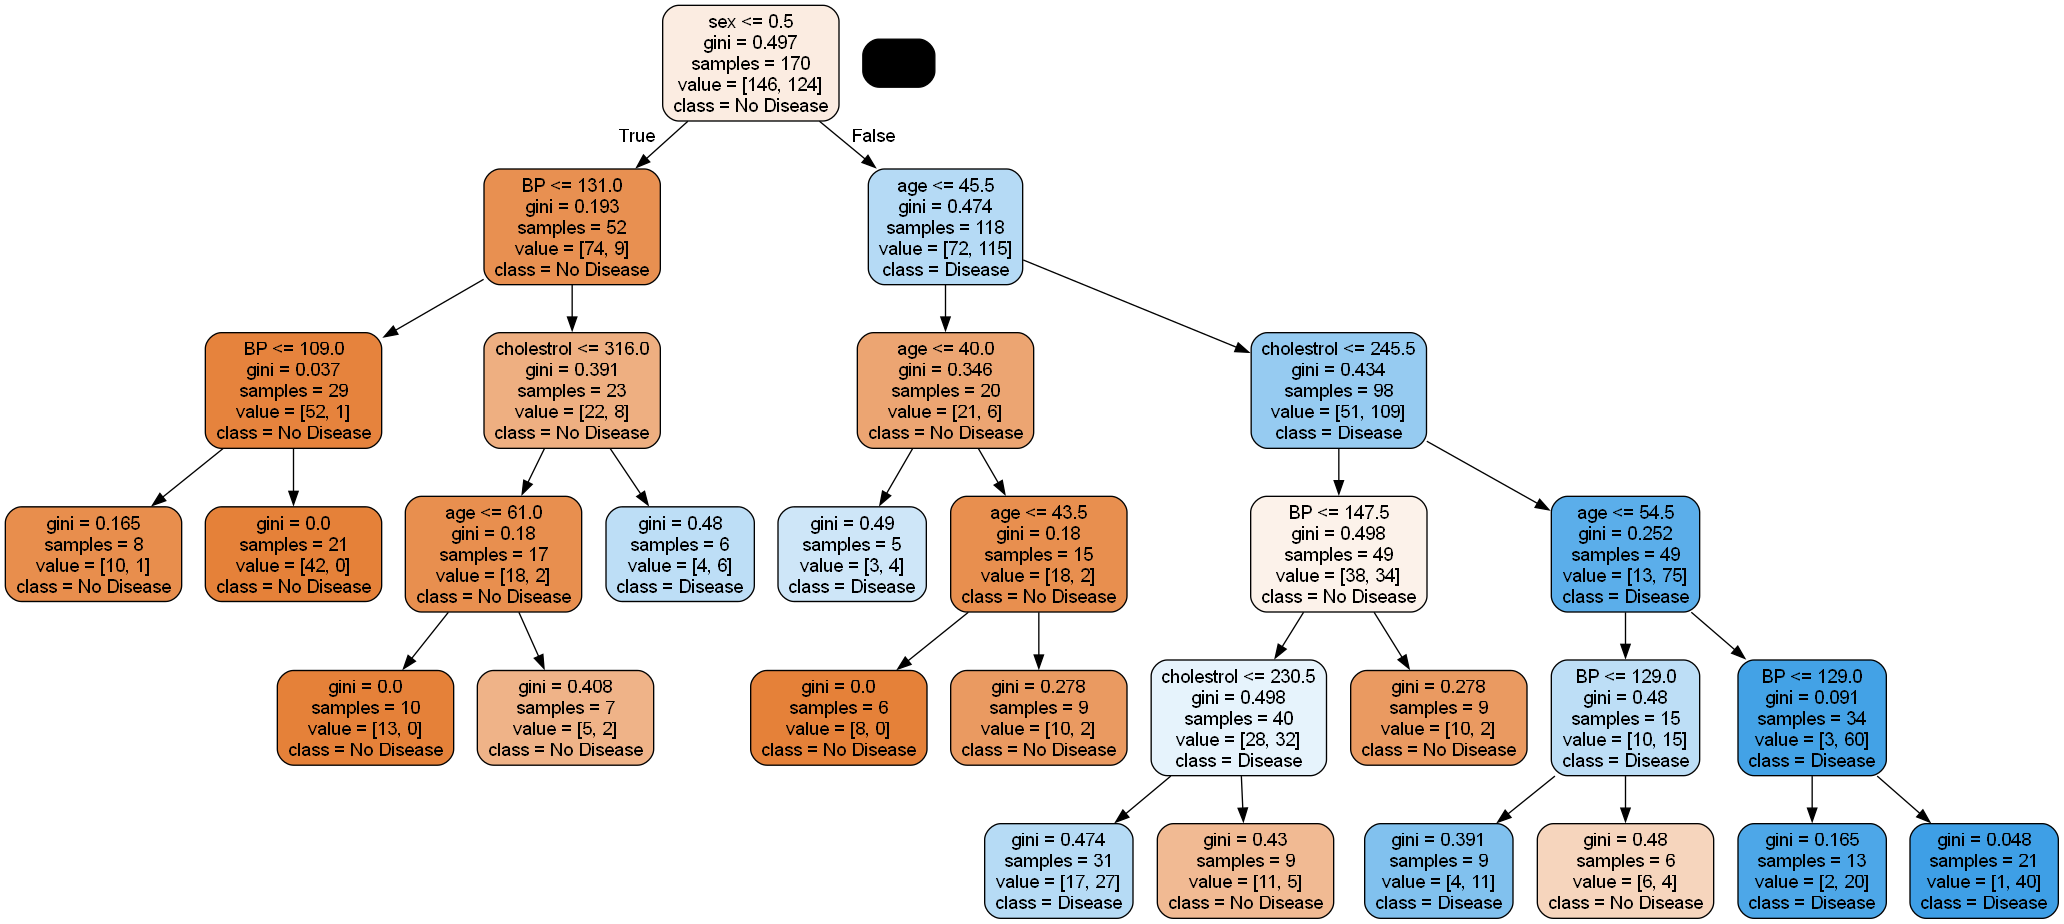

In [30]:
graph_best = get_dt_graph(sample_tree_best)
Image(graph_best.create_png())

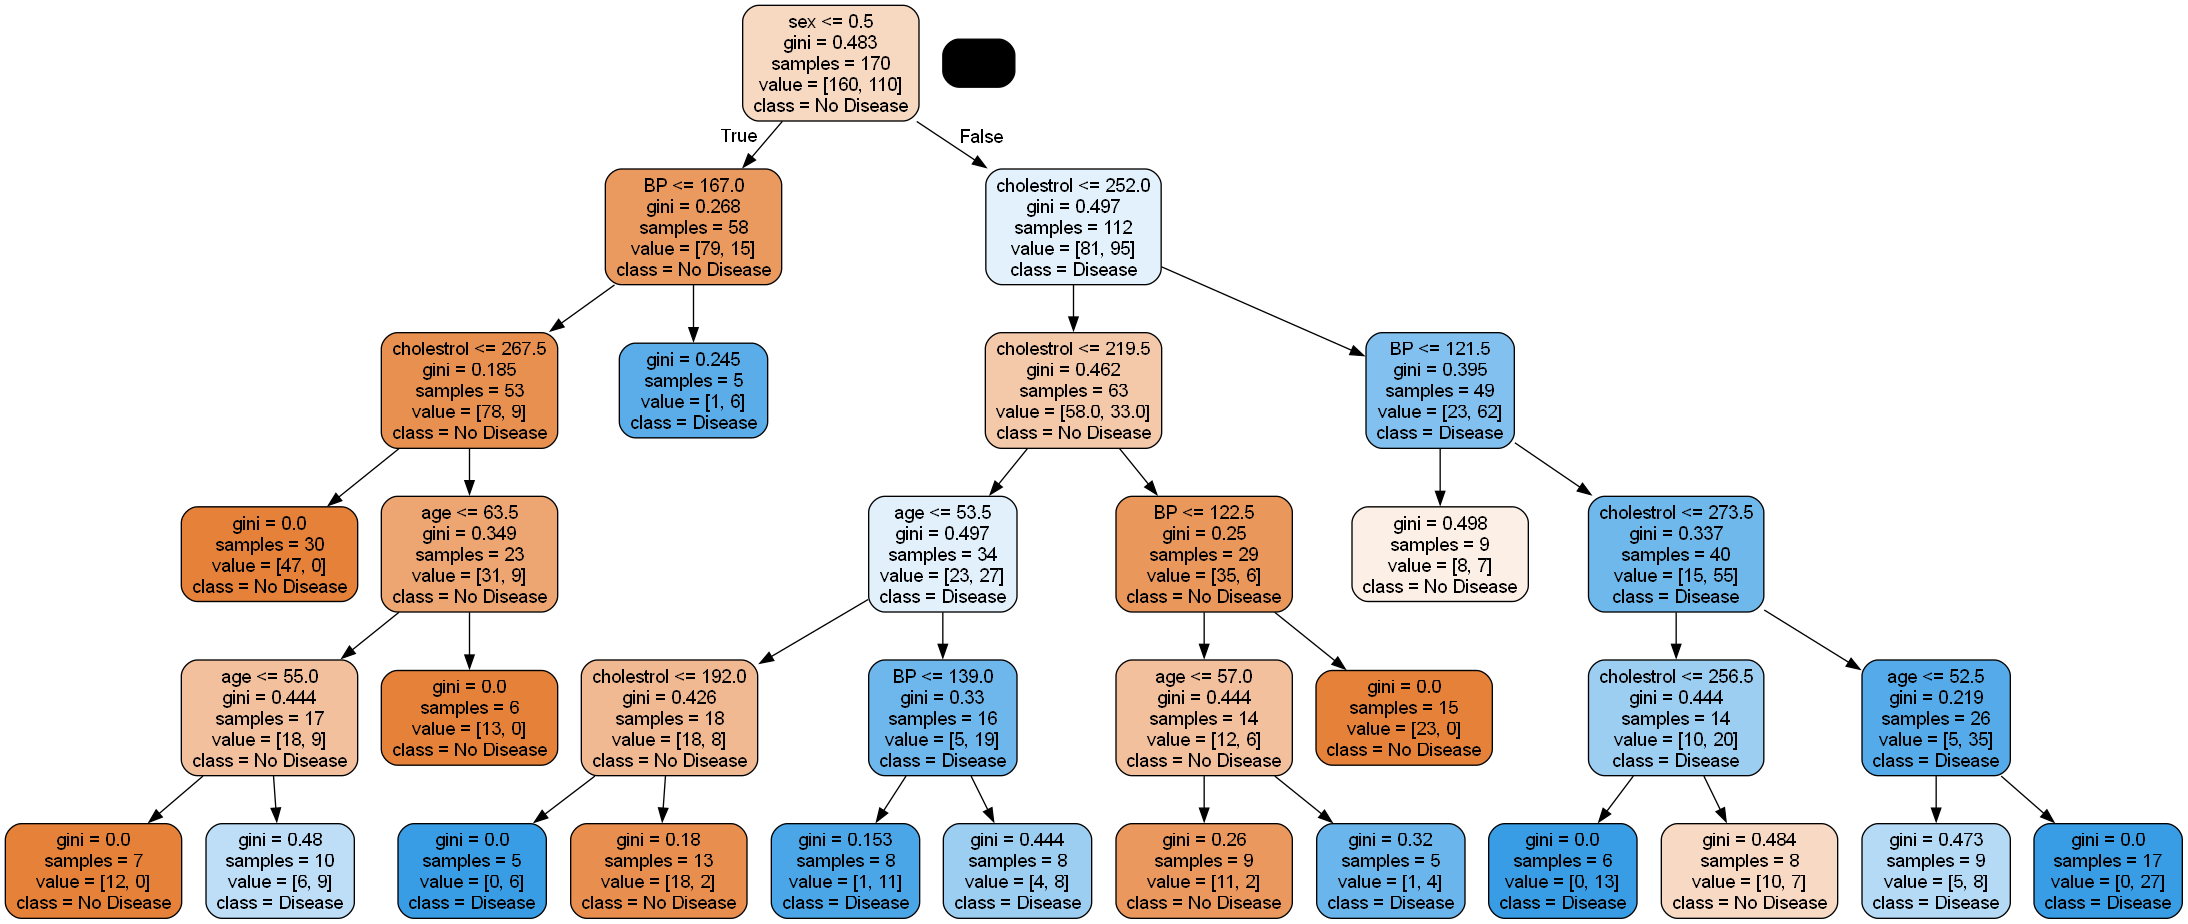

In [31]:
sample_tree_best2 = get_dt_graph(rf_best.estimators_[10])
Image(sample_tree_best2.create_png()) 

# Variable Importance in RandomForest and Decision Trees  

In [32]:
classifier_rf1 = RandomForestClassifier(random_state=42,n_jobs=-1,
                                        max_depth=5,n_estimators=100,oob_score=True)

In [33]:
classifier_rf1.fit(X_train,y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [34]:
classifier_rf1.feature_importances_

array([0.37539743, 0.13780788, 0.20834585, 0.27844883])

In [35]:
imp_df = pd.DataFrame({
    "Varname": X_train.columns,
    "Imp": classifier_rf1.feature_importances_
})

In [36]:
imp_df.sort_values(by="Imp", ascending=False)

,Varname,Imp
0,age,0.375397
3,cholestrol,0.278449
2,BP,0.208346
1,sex,0.137808
